Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202408010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202409010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202410010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202411010000.feather
Processing Trading-price/PUBLIC_ARCHIVE#TRADINGPRICE#FILE01#202412010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202310010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202311010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202312010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202401010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202402010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202403010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202404010000.feather
Processing Trading-price/PUBLIC_DVD_TRADINGPRICE_202405010000.feather
Processing Trading-price/PUBLIC_DVD

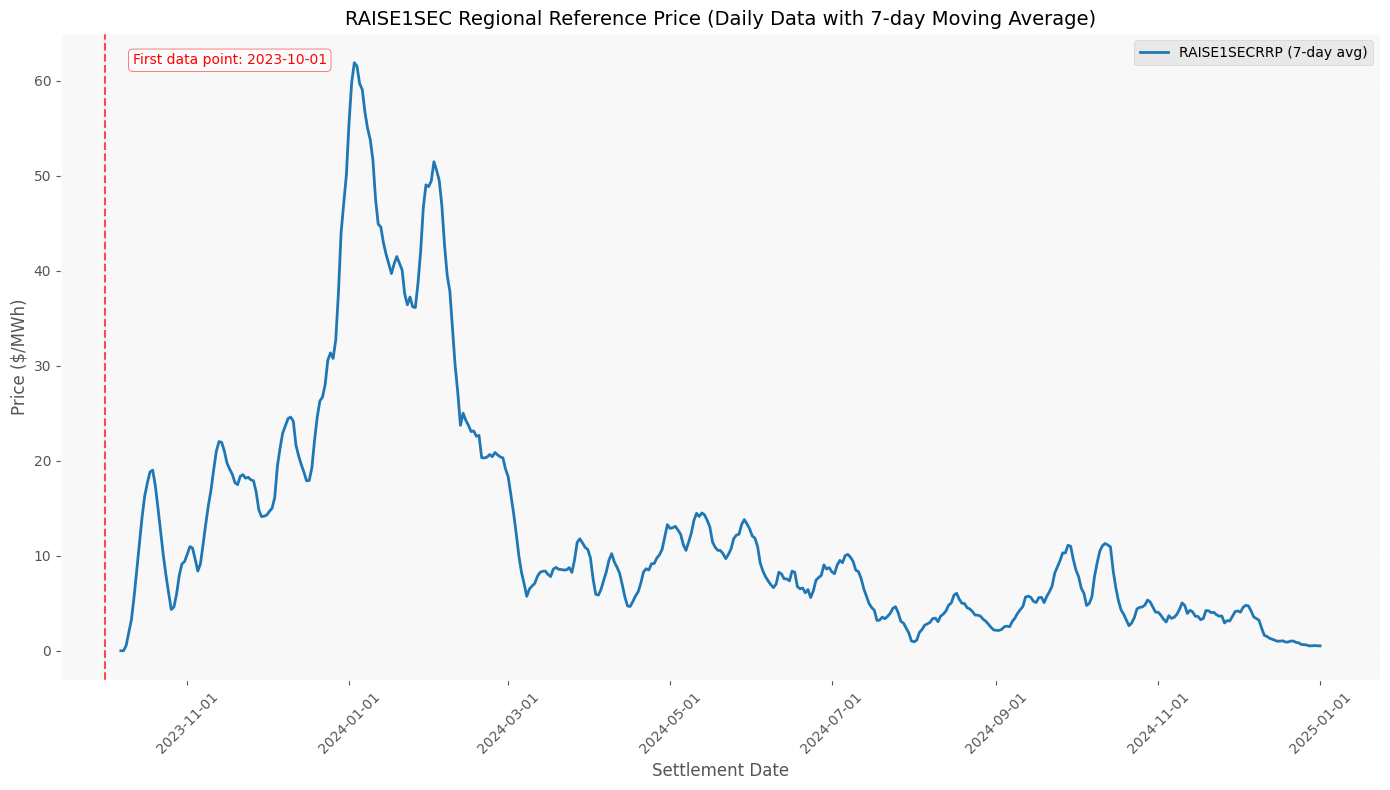

In [5]:
import boto3
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import BytesIO

# Set styling for better visuals
plt.style.use('ggplot')  # A clean built-in style
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# S3 connection code remains the same
s3 = boto3.client('s3')
bucket_name = 'thesis--ec331-s3'
prefix = 'Trading-price/'
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
all_data = pd.DataFrame()

# Loop through files
for obj in response.get('Contents', []):
    file_key = obj['Key']
    if file_key.endswith('.feather'):
        print(f"Processing {file_key}")
        response = s3.get_object(Bucket=bucket_name, Key=file_key)
        file_content = response['Body'].read()
        bytes_buffer = BytesIO(file_content)
        df = feather.read_feather(bytes_buffer)
        all_data = pd.concat([all_data, df], ignore_index=True)

print(f"Total rows: {len(all_data)}")

# Data preprocessing
all_data['SETTLEMENTDATE'] = pd.to_datetime(all_data['SETTLEMENTDATE'])
all_data['RAISE1SECRRP'] = pd.to_numeric(all_data['RAISE1SECRRP'], errors='coerce')

# Sort by date
all_data = all_data.sort_values('SETTLEMENTDATE')

# Get the first date in the dataset
first_date = all_data['SETTLEMENTDATE'].min()
print(f"First date in dataset: {first_date}")

# Outlier removal using quantiles
q_low_rrp = all_data['RAISE1SECRRP'].quantile(0.01)
q_high_rrp = all_data['RAISE1SECRRP'].quantile(0.99)

filtered_data = all_data[(all_data['RAISE1SECRRP'] >= q_low_rrp) & 
                         (all_data['RAISE1SECRRP'] <= q_high_rrp)]

# STEP 1: Resample to daily data with numeric_only=True to fix the warning
daily_data = filtered_data.set_index('SETTLEMENTDATE').resample('D').mean(numeric_only=True).reset_index()

# STEP 2: Apply a 7-day moving average for additional smoothing
daily_data['RAISE1SECRRP_SMOOTH'] = daily_data['RAISE1SECRRP'].rolling(window=7).mean()
daily_data = daily_data.dropna(subset=['RAISE1SECRRP_SMOOTH'])

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the RRP line (blue)
ax.plot(daily_data['SETTLEMENTDATE'], daily_data['RAISE1SECRRP_SMOOTH'], 
        label='RAISE1SECRRP (7-day avg)', linewidth=2, color='#1f77b4')

# Add a vertical line to mark the first date of the market
ax.axvline(x=first_date, color='red', linestyle='--', alpha=0.7)
ax.annotate(f'First data point: {first_date.strftime("%Y-%m-%d")}', 
            xy=(first_date, ax.get_ylim()[1]*0.95),
            xytext=(20, 0),  # 20 points to the right
            textcoords='offset points',
            color='red',
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.7))

# Format the x-axis to show dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Enhance the overall look
ax.set_title('RAISE1SEC Regional Reference Price (Daily Data with 7-day Moving Average)', fontsize=14)
ax.set_xlabel('Settlement Date', fontsize=12)
ax.set_ylabel('Price ($/MWh)', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Enhance legend
ax.legend(frameon=True, loc='upper right')

# Add a light background color to make the plot stand out
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('raise1sec_rrp_smooth.png', dpi=300, bbox_inches='tight')
plt.show()